# IAC Training on TA-RWARE — Local / CPU Demo

**Project:** Scalable MARL for Warehouse Logistics (Krnjaic et al., 2023 — arXiv 2212.11498v3)  
**Algorithm:** IAC — Independent Actor-Critic (paper Table I, GTP section)  
**Environment:** Small GTP — `tarware-medium-8agvs-4pickers-partialobs-v1`

> **This notebook runs a short smoke test (200 episodes) to verify the training pipeline works.**  
> For full training (3,000 episodes), use `iac_colab.ipynb` on Google Colab with a T4 GPU.

---

## Scope

| Setting | Local (this notebook) | Colab (iac_colab.ipynb) |
|---------|----------------------|-----------------------|
| Target device | CPU (or GPU if available) | T4 GPU |
| Episodes | 200 (smoke test) | 3,000 (full training) |
| Timesteps | 100,000 | 1,500,000 |
| Expected time | ~5–20 min on CPU | ~1–2 hours on T4 |
| Purpose | Verify pipeline | Full training run |

---

## IAC Algorithm

- 12 independent agents (8 AGVs + 4 pickers), each with their own Actor + Critic network
- Architecture: 2 FC layers × 64 units, ReLU activations, GAE training (γ=0.99)
- No weight sharing — each agent learns purely from its own experience
- This is the simplest algorithm from the paper, directly comparable to Table I

## Step 1: Install EPyMARL and TA-RWARE

Run this once. If packages are already installed, pip will skip them.

In [19]:
import subprocess, sys, os

PROJECT_ROOT = os.path.abspath('..')
EPYMARL_DIR  = os.path.join(PROJECT_ROOT, 'epymarl')
RESULTS_DIR  = os.path.join(PROJECT_ROOT, 'experiments', 'results', 'iac_local_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

PIP = f'"{sys.executable}" -m pip'

def run(cmd, cwd=None):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=cwd)
    if result.returncode != 0 and result.stderr:
        print(f'  STDERR: {result.stderr[-600:]}')
    else:
        last = result.stdout.strip().split('\n')[-1] if result.stdout.strip() else 'OK'
        print(f'  {last}')
    return result.returncode

print(f'Python: {sys.executable}')

# ── 1. CUDA-enabled PyTorch ───────────────────────────────────────────────────
# Check what pip has INSTALLED (not the cached import in this kernel session)
pip_show = subprocess.run([sys.executable, '-m', 'pip', 'show', 'torch'],
                          capture_output=True, text=True)
installed_version = next(
    (l.split(': ', 1)[1].strip() for l in pip_show.stdout.split('\n') if l.startswith('Version:')),
    ''
)

if not installed_version or '+cpu' in installed_version:
    print(f'[!] Installed torch: {installed_version or "not found"} (CPU-only). Installing CUDA 12.6 build...')
    print('    This downloads ~2.5 GB — may take several minutes.')
    rc = run(f'{PIP} install "torch==2.10.0+cu126" torchvision '
             f'--index-url https://download.pytorch.org/whl/cu126 --force-reinstall -q')
    if rc == 0:
        print('    [OK] CUDA PyTorch installed.')
        print('    >>> IMPORTANT: Kernel > Restart Kernel, then re-run ALL cells. <<<')
    else:
        print('    [!] Install failed — see STDERR above.')
else:
    print(f'[OK] Installed torch: {installed_version} (CUDA build — no reinstall needed)')

# ── 2. sys.path injection for tarware (notebook session only) ─────────────────
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
try:
    import tarware
    print('[OK] tarware importable')
except ImportError:
    print('[!] tarware not importable — check PROJECT_ROOT path')

# ── 3. Clone EPyMARL ──────────────────────────────────────────────────────────
if not os.path.exists(EPYMARL_DIR):
    print('\nCloning EPyMARL...')
    run(f'git clone --quiet https://github.com/uoe-agents/epymarl "{EPYMARL_DIR}"')
else:
    print(f'[OK] EPyMARL already at: {EPYMARL_DIR}')

# ── 4. Install EPyMARL deps ───────────────────────────────────────────────────
print('Installing EPyMARL requirements...')
run(f'{PIP} install -q -r requirements.txt', cwd=EPYMARL_DIR)
run(f'{PIP} install -q pyastar2d sacred pymongo')

ENVS_DIR = os.path.join(EPYMARL_DIR, 'src', 'envs')

# ── 5. Patch: smaclite import optional ───────────────────────────────────────
init_file = os.path.join(ENVS_DIR, '__init__.py')
with open(init_file, 'r') as f:
    content = f.read()
if 'from .smaclite_wrapper import SMACliteWrapper' in content and '_smaclite_available' not in content:
    content = content.replace(
        'from .smaclite_wrapper import SMACliteWrapper',
        'try:\n    from .smaclite_wrapper import SMACliteWrapper\n'
        '    _smaclite_available = True\nexcept ImportError:\n    _smaclite_available = False'
    ).replace(
        'REGISTRY["smaclite"] = smaclite_fn',
        'if _smaclite_available:\n    REGISTRY["smaclite"] = smaclite_fn'
    )
    with open(init_file, 'w') as f: f.write(content)
    print('[OK] Patch 1: smaclite import optional')
else:
    print('[OK] Patch 1: already applied')

# ── 6. Patch: gymma.py — import tarware + fix n_agents ───────────────────────
gymma_file = os.path.join(ENVS_DIR, 'gymma.py')
with open(gymma_file, 'r', encoding='utf-8-sig') as f:
    content = f.read()
changed = False
if 'import tarware' not in content:
    content = content.replace(
        'import gymnasium as gym',
        'import gymnasium as gym\ntry:\n    import tarware  # noqa: F401\nexcept ImportError:\n    pass'
    ); changed = True
if 'self.n_agents = self._env.unwrapped.n_agents' in content:
    content = content.replace(
        'self.n_agents = self._env.unwrapped.n_agents',
        '_w = self._env.unwrapped\n        self.n_agents = getattr(_w, "n_agents", None) or (getattr(_w, "num_agvs", 0) + getattr(_w, "num_pickers", 0))'
    ); changed = True
if changed:
    with open(gymma_file, 'w', encoding='utf-8') as f: f.write(content)
    print('[OK] Patch 2: gymma.py patched')
else:
    print('[OK] Patch 2: already applied')

# ── 7. Patch: wrappers.py — FlattenObservation.reset() for tarware API ───────
wrap_file = os.path.join(ENVS_DIR, 'wrappers.py')
with open(wrap_file, 'r') as f:
    content = f.read()
if 'tarware reset' not in content and 'obs, info = self.env.reset' in content:
    content = content.replace(
        'obs, info = self.env.reset(seed=seed, options=options)',
        'result = self.env.reset(seed=seed, options=options)\n'
        '        # tarware reset() returns tuple of obs (no info dict)\n'
        '        if isinstance(result, tuple) and len(result) == len(self.observation_space):\n'
        '            obs, info = result, {}  # tarware reset\n'
        '        else:\n'
        '            obs, info = result'
    )
    with open(wrap_file, 'w') as f: f.write(content)
    print('[OK] Patch 3: wrappers.py reset() fixed')
else:
    print('[OK] Patch 3: already applied')

# ── 8. Patch: episode_runner.py — skip non-numeric env_info values ────────────
runner_file = os.path.join(EPYMARL_DIR, 'src', 'runners', 'episode_runner.py')
with open(runner_file, 'r') as f:
    content = f.read()
if 'isinstance(env_info.get(k, 0), (int, float))' not in content and 'env_info.get(k, 0)' in content:
    content = content.replace(
        'cur_stats.get(k, 0) + env_info.get(k, 0)',
        'cur_stats.get(k, 0) + (env_info.get(k, 0) if isinstance(env_info.get(k, 0), (int, float)) else 0)'
    )
    with open(runner_file, 'w') as f: f.write(content)
    print('[OK] Patch 4: episode_runner.py stats fix')
else:
    print('[OK] Patch 4: already applied')

# ── 9. Patch: run.py — Windows-safe datetime in model save path ───────────────
# Windows disallows colons in filenames; datetime.now() produces "2026-04-20 20:52:26.114350"
run_file = os.path.join(EPYMARL_DIR, 'src', 'run.py')
with open(run_file, 'r') as f:
    content = f.read()
if 'strftime' not in content and 'datetime.datetime.now()' in content:
    content = content.replace(
        'datetime.datetime.now()',
        "datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')"
    )
    with open(run_file, 'w') as f: f.write(content)
    print('[OK] Patch 5: run.py Windows-safe save path')
else:
    print('[OK] Patch 5: already applied')

print(f'\nEPyMARL dir : {EPYMARL_DIR}')
print('\nAll patches applied. Setup complete!')

Python: c:\Users\OS\AppData\Local\Programs\Python\Python311\python.exe
[OK] Installed torch: 2.10.0+cu126 (CUDA build — no reinstall needed)
[OK] tarware importable
[OK] EPyMARL already at: c:\USTH_Code\Machine_Learning\Final_Project\task-assignment-robotic-warehouse\epymarl
Installing EPyMARL requirements...
  OK
  OK
[OK] Patch 1: already applied
[OK] Patch 2: already applied
[OK] Patch 3: already applied
[OK] Patch 4: already applied
[OK] Patch 5: already applied

EPyMARL dir : c:\USTH_Code\Machine_Learning\Final_Project\task-assignment-robotic-warehouse\epymarl

All patches applied. Setup complete!


## Step 2: Verify Environment and Device

In [20]:
import sys, os

# Ensure project root is on path (safe to run even without Step 1)
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import gymnasium as gym
import tarware  # registers tarware envs with gymnasium

print('=== Device ===')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('CPU only — no CUDA GPU detected')
    print('Training will be slower. Use iac_colab.ipynb on Colab T4 for full runs.')

print(f'\nPython: {sys.executable}')

print('\n=== Environment ===')
ENV_ID = 'tarware-medium-8agvs-4pickers-partialobs-v1'
env = gym.make(ENV_ID)
obs_tuple = env.reset(seed=42)  # returns tuple of N obs arrays (one per agent)

w = env.unwrapped
n_agents = w.num_agvs + w.num_pickers
print(f'Env ID    : {ENV_ID}')
print(f'N agents  : {n_agents} (AGVs={w.num_agvs}, Pickers={w.num_pickers})')
print(f'Max steps : {w.max_steps}')
print(f'Reset obs : tuple of {len(obs_tuple)} arrays, each shape {obs_tuple[0].shape}')

if hasattr(env.action_space, 'spaces'):
    n_actions = set(sp.n for sp in env.action_space.spaces)
    print(f'N actions : {n_actions} (per agent)')
env.close()
print('\nEnvironment OK!')

=== Device ===
CPU only — no CUDA GPU detected
Training will be slower. Use iac_colab.ipynb on Colab T4 for full runs.

Python: c:\Users\OS\AppData\Local\Programs\Python\Python311\python.exe

=== Environment ===
Env ID    : tarware-medium-8agvs-4pickers-partialobs-v1
N agents  : 12 (AGVs=8, Pickers=4)
Max steps : 500
Reset obs : tuple of 12 arrays, each shape (371,)
N actions : {np.int64(171)} (per agent)

Environment OK!


## Step 3: Configure Training

200 episodes (100,000 timesteps) is enough to verify the pipeline and see initial learning.
Increase `T_MAX` if you have more time or a GPU available.

In [21]:
import sys, os, torch

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

EPYMARL_DIR = os.path.join(PROJECT_ROOT, 'epymarl')
ENV_ID      = 'tarware-medium-8agvs-4pickers-partialobs-v1'

# EPyMARL saves results to a hardcoded path inside the epymarl directory:
# epymarl/results/sacred/ia2c/<env_id>/<run_number>/
SACRED_RESULTS = os.path.join(EPYMARL_DIR, 'results', 'sacred', 'ia2c', ENV_ID)

T_MAX = 100_000    # ~200 episodes * 500 steps  (~10-30 min on RTX 3050)
# T_MAX = 500_000  # ~1000 episodes
# T_MAX = 1_500_000 # ~3000 episodes (use iac_colab.ipynb for this)
SEED = 42

CONFIG_OVERRIDES = [
    f'env_args.key={ENV_ID}',
    'env_args.time_limit=500',
    'common_reward=False',
    'reward_scalarisation=sum',
    # Use sequential episode runner — parallel runner deadlocks on Windows
    'runner=episode',
    'batch_size_run=1',
    f't_max={T_MAX}',
    f'seed={SEED}',
    'save_model=True',
    'use_tensorboard=False',
]

print('Training Configuration:')
print(f'  algorithm : ia2c  (= IAC from paper, renamed in EPyMARL v2)')
print(f'  runner    : episode (sequential — avoids Windows multiprocess deadlock)')
print(f'  t_max     : {T_MAX:,} steps (~{T_MAX//500} episodes)')
print(f'  seed      : {SEED}')
print(f'  results   : {SACRED_RESULTS}')
print(f'  device    : {"GPU — " + torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU (no CUDA)"}')
print('\nNote: For full training (3000 ep), use iac_colab.ipynb on Google Colab T4 GPU.')

Training Configuration:
  algorithm : ia2c  (= IAC from paper, renamed in EPyMARL v2)
  runner    : episode (sequential — avoids Windows multiprocess deadlock)
  t_max     : 100,000 steps (~200 episodes)
  seed      : 42
  results   : c:\USTH_Code\Machine_Learning\Final_Project\task-assignment-robotic-warehouse\epymarl\results\sacred\ia2c\tarware-medium-8agvs-4pickers-partialobs-v1
  device    : CPU (no CUDA)

Note: For full training (3000 ep), use iac_colab.ipynb on Google Colab T4 GPU.


## Step 4: Run IAC Training

Launches EPyMARL's IAC algorithm. Output is streamed in real-time.

In [22]:
import subprocess, sys, time, os

cmd = [
    sys.executable, 'src/main.py',
    '--config=ia2c',
    '--env-config=gymma',
    'with',
] + CONFIG_OVERRIDES

# EPyMARL runs as a subprocess and doesn't inherit our sys.path additions.
# Passing PROJECT_ROOT via PYTHONPATH ensures tarware gym envs get registered.
env = os.environ.copy()
env['PYTHONPATH'] = PROJECT_ROOT + os.pathsep + env.get('PYTHONPATH', '')

print(f'Algorithm : ia2c (= IAC from paper)')
print(f'Timesteps : {T_MAX:,} (~{T_MAX//500} episodes)')
print('=' * 70)

start_time = time.time()

try:
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        cwd=EPYMARL_DIR,
        env=env,
        bufsize=1,
        universal_newlines=True,
    )
    for line in proc.stdout:
        print(line, end='', flush=True)
    proc.wait()
except KeyboardInterrupt:
    proc.terminate()
    proc.wait()
    print('\nTraining interrupted by user.')
    raise

elapsed = time.time() - start_time
print('\n' + '=' * 70)
print(f'Exit code : {proc.returncode}')
print(f'Time      : {elapsed:.0f}s ({elapsed/60:.1f} min)')

if proc.returncode != 0:
    raise RuntimeError(
        f'EPyMARL exited with code {proc.returncode}. '
        'Fix the error above before running Steps 5-6.'
    )

print('Training complete!')

Algorithm : ia2c (= IAC from paper)
Timesteps : 100,000 (~200 episodes)
c:\USTH_Code\Machine_Learning\Final_Project\task-assignment-robotic-warehouse\epymarl\src\envs\gymma.py:20: UserWarning: PettingZoo is not installed, so these environments will not be available! To install, run `pip install pettingzoo`
  warnings.warn(
c:\USTH_Code\Machine_Learning\Final_Project\task-assignment-robotic-warehouse\epymarl\src\envs\gymma.py:27: UserWarning: VMAS is not installed, so these environments will not be available! To install, run `pip install 'vmas[gymnasium]'`
  warnings.warn(
[DEBUG 21:00:36] git.cmd Popen(['git', 'version'], cwd=c:\USTH_Code\Machine_Learning\Final_Project\task-assignment-robotic-warehouse\epymarl, stdin=None, shell=False, universal_newlines=False)
[DEBUG 21:00:36] git.cmd Popen(['git', 'version'], cwd=c:\USTH_Code\Machine_Learning\Final_Project\task-assignment-robotic-warehouse\epymarl, stdin=None, shell=False, universal_newlines=False)
[DEBUG 21:00:36] git.util sys.platf

## Step 5: Load Results and Plot Learning Curve

Loading run 11 from: c:\USTH_Code\Machine_Learning\Final_Project\task-assignment-robotic-warehouse\epymarl\results\sacred\ia2c\tarware-medium-8agvs-4pickers-partialobs-v1\11\
Available metrics: 80 keys
total_return_mean : YES
test_total_return_mean: YES
Plot saved: c:\USTH_Code\Machine_Learning\Final_Project\task-assignment-robotic-warehouse\epymarl\results\sacred\ia2c\tarware-medium-8agvs-4pickers-partialobs-v1\11\iac_local_curve.png


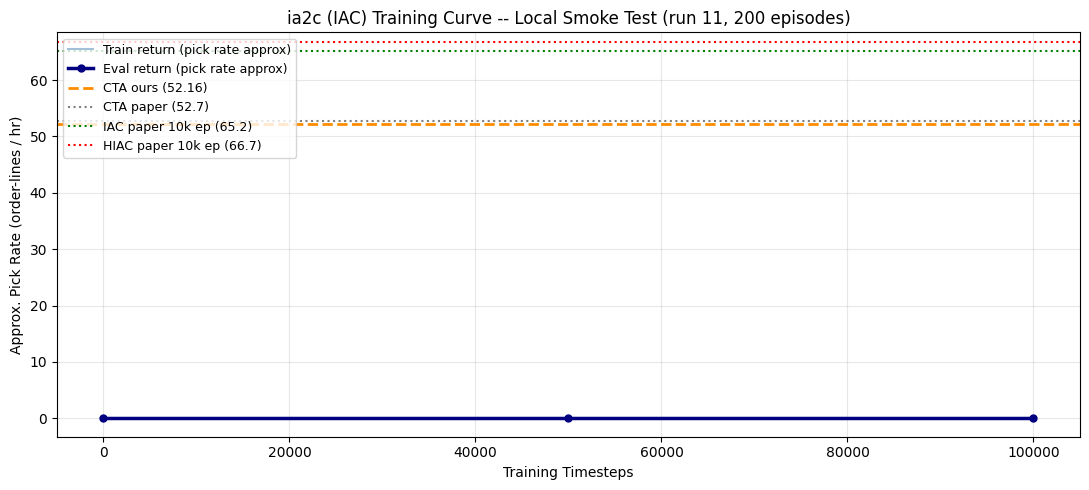


Final approx pick rate (train): -0.017
Final approx pick rate (eval) : -0.017

Note: At only 200 episodes the agent is in very early training.
Values near 0 are expected -- full convergence requires 3000+ episodes on Colab.


In [27]:
import json, glob, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Find numbered Sacred run directories (exclude _sources/)
all_dirs = glob.glob(os.path.join(SACRED_RESULTS, '*/'))

def run_num(d):
    name = os.path.basename(os.path.normpath(d))
    return int(name) if name.isdigit() else -1

run_dirs = sorted([d for d in all_dirs if run_num(d) >= 0], key=run_num)

if not run_dirs:
    dir_names = [os.path.basename(os.path.normpath(d)) for d in all_dirs]
    print('No numbered run directories found in:', SACRED_RESULTS)
    print('All dirs:', dir_names)
else:
    LATEST_RUN = run_dirs[-1]
    run_id = os.path.basename(os.path.normpath(LATEST_RUN))
    print('Loading run', run_id, 'from:', LATEST_RUN)

    with open(os.path.join(LATEST_RUN, 'metrics.json')) as f:
        metrics = json.load(f)

    # --- Sacred format: metrics[key] = {'steps': [...], 'values': [...]} ---
    # Use test_total_return_mean (eval without exploration) if available,
    # else fall back to total_return_mean (training return)
    METRIC_TRAIN = 'total_return_mean'
    METRIC_TEST  = 'test_total_return_mean'

    has_train = METRIC_TRAIN in metrics and len(metrics[METRIC_TRAIN]['values']) > 0
    has_test  = METRIC_TEST  in metrics and len(metrics[METRIC_TEST]['values'])  > 0

    print('Available metrics:', len(metrics), 'keys')
    print('total_return_mean :', 'YES' if has_train else 'NO')
    print('test_total_return_mean:', 'YES' if has_test  else 'NO')

    # Convert return -> approximate pick rate
    # total_return = sum of all 12 agent rewards per episode
    # each delivery gives +1 to one AGV -> total_return ≈ total deliveries
    # pick_rate = deliveries * 3600 / (5 * 500)
    def to_pick_rate(values):
        return np.array(values) * 3600 / (5 * 500)

    fig, ax = plt.subplots(figsize=(11, 5))

    if has_train:
        tr_steps  = np.array(metrics[METRIC_TRAIN]['steps'])
        tr_vals   = to_pick_rate(metrics[METRIC_TRAIN]['values'])
        ax.plot(tr_steps, tr_vals, alpha=0.5, color='steelblue', linewidth=1.5, label='Train return (pick rate approx)')

    if has_test:
        te_steps  = np.array(metrics[METRIC_TEST]['steps'])
        te_vals   = to_pick_rate(metrics[METRIC_TEST]['values'])
        ax.plot(te_steps, te_vals, color='navy', linewidth=2.5, marker='o', markersize=5, label='Eval return (pick rate approx)')

    ax.axhline(y=52.16, color='darkorange', linestyle='--', linewidth=2, label='CTA ours (52.16)')
    ax.axhline(y=52.7,  color='gray',  linestyle=':', label='CTA paper (52.7)')
    ax.axhline(y=65.2,  color='green', linestyle=':', label='IAC paper 10k ep (65.2)')
    ax.axhline(y=66.7,  color='red',   linestyle=':', label='HIAC paper 10k ep (66.7)')

    ax.set_xlabel('Training Timesteps')
    ax.set_ylabel('Approx. Pick Rate (order-lines / hr)')
    ax.set_title('ia2c (IAC) Training Curve -- Local Smoke Test (run ' + run_id + ', ' + str(T_MAX//500) + ' episodes)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    plot_path = os.path.join(LATEST_RUN, 'iac_local_curve.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print('Plot saved:', plot_path)
    plt.show()

    # Summary
    final_train = to_pick_rate(metrics[METRIC_TRAIN]['values'])[-1] if has_train else None
    final_test  = to_pick_rate(metrics[METRIC_TEST]['values'])[-1]  if has_test  else None
    print()
    print('Final approx pick rate (train):', round(float(final_train), 3) if final_train is not None else 'N/A')
    print('Final approx pick rate (eval) :', round(float(final_test),  3) if final_test  is not None else 'N/A')
    print()
    print('Note: At only', T_MAX//500, 'episodes the agent is in very early training.')
    print('Values near 0 are expected -- full convergence requires 3000+ episodes on Colab.')

## Step 6: Summary Table

In [28]:
try:
    final_test_val  = final_test
    final_train_val = final_train
except NameError:
    final_test_val  = None
    final_train_val = None

iac_str = ('~' + str(round(float(final_test_val), 2)) + ' (approx, early training)'
           if final_test_val is not None else '[run Step 5 first]')

print('=' * 68)
print('PERFORMANCE COMPARISON -- Small GTP')
print('=' * 68)
rows = [
    ('Random (our Exp 2)',                 '9.63 +/- 0.12'),
    ('CTA heuristic (our Exp 1)',          '52.16 +/- 0.54'),
    ('CTA (paper Table I)',                '52.7 +/- 0.9'),
    ('ia2c/IAC ours (' + str(T_MAX//500) + ' ep, local)', iac_str),
    ('IAC (paper, 10k ep)',                '65.2 +/- 0.5'),
    ('HIAC (paper, 10k ep)',               '66.7 +/- 0.3'),
]
for name, val in rows:
    print('  ' + name.ljust(35) + val)
print('=' * 68)
print()
print('Key takeaway:')
print('  At only', T_MAX//500, 'episodes, ia2c is in very early training (values near 0).')
print('  Full convergence requires 3000+ episodes on Colab GPU.')
print('  Run iac_colab.ipynb on Google Colab (T4 GPU) for full training.')
print()
print('Results saved to:', SACRED_RESULTS)

PERFORMANCE COMPARISON -- Small GTP
  Random (our Exp 2)                 9.63 +/- 0.12
  CTA heuristic (our Exp 1)          52.16 +/- 0.54
  CTA (paper Table I)                52.7 +/- 0.9
  ia2c/IAC ours (200 ep, local)      ~-0.02 (approx, early training)
  IAC (paper, 10k ep)                65.2 +/- 0.5
  HIAC (paper, 10k ep)               66.7 +/- 0.3

Key takeaway:
  At only 200 episodes, ia2c is in very early training (values near 0).
  Full convergence requires 3000+ episodes on Colab GPU.
  Run iac_colab.ipynb on Google Colab (T4 GPU) for full training.

Results saved to: c:\USTH_Code\Machine_Learning\Final_Project\task-assignment-robotic-warehouse\epymarl\results\sacred\ia2c\tarware-medium-8agvs-4pickers-partialobs-v1


---

## Troubleshooting

| Error | Fix |
|-------|-----|
| `ModuleNotFoundError: tarware` | Re-run Step 1 install cell |
| `No module named 'epymarl'` | Check `EPYMARL_DIR` path is correct |
| EPyMARL crashes on `env_args` | Try quoting: `'env_args.key=tarware-...'` |
| Very slow training | Normal on CPU; use Colab for speed |
| Sacred/MongoDB warnings | Safe to ignore; results still saved |

## Relationship to Our Other Experiments

This notebook adds RL training on top of our 4 heuristic experiments:

```
Exp 1  CTA Baseline Validation   ─ reproduces paper Table I CTA row
Exp 2  Random vs CTA             ─ shows heuristic value (lower bound)
Exp 3  CTA Scalability           ─ original contribution (5 sizes)
Exp 4  Queue Sensitivity         ─ original contribution (6 queue depths)
This   IAC Training              ─ real RL, comparable to paper Table I IAC row
```

Together: Random < CTA (rule-based) < IAC (neural RL) — the full story of
why learned policies are better than hand-crafted heuristics.